In [1]:
# DT and random forset exploration with NYC airbnb data
import pandas as pd
airbnb_df = pd.read_csv('../data/AB_NYC_2019.csv')

airbnb_df.describe()
airbnb_df.info()
airbnb_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# NULL count per columns
na_counts = {}
columns = airbnb_df.columns
for col in columns:
    data = airbnb_df[col]
    count = data[data.isna() | data.isnull()].size
    if count > 0:
        na_counts[col] = count
        
print(na_counts)

{'name': 16, 'host_name': 21, 'last_review': 10052, 'reviews_per_month': 10052}


In [3]:
# let's take another data NYC housing price
housingprice_df = pd.read_csv('../data/nyc_housing_base.csv')

housingprice_df.describe()
housingprice_df.info()
housingprice_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  str    
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  str    
 18  building_age  34439 non-null  float64

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


In [4]:
# NULL count per columns
na_counts = {}
columns = housingprice_df.columns
for col in columns:
    data = housingprice_df[col]
    count = data[data.isna() | data.isnull()].size
    if count > 0:
        na_counts[col] = count
        
print(na_counts)

{'zip_code': 16, 'resarea': 188, 'comarea': 188, 'numfloors': 43, 'latitude': 6, 'longitude': 6, 'landuse': 3}


In [5]:
# find category variables frequency count
cat_var = ['borough_x', 'zip_code', 'borough_y', 'landuse', 'bldgclass']
for col in cat_var:
    print(col)
    print('=====================')
    print(housingprice_df.groupby(col).size())

borough_x
borough_x
1     6721
2     3389
3     8761
4    11770
5     3798
dtype: int64
zip_code
zip_code
10001.0    113
10002.0    155
10003.0    387
10004.0      8
10005.0      8
          ... 
11692.0     76
11693.0     53
11694.0    104
11695.0     49
11697.0      4
Length: 180, dtype: int64
borough_y
borough_y
BK     9911
BX     3393
MN     4018
QN    13168
SI     3949
dtype: int64
landuse
landuse
1.0     18664
2.0      5559
3.0      7010
4.0      1725
5.0       700
6.0       308
7.0       139
8.0       215
9.0         3
10.0      110
11.0        3
dtype: int64
bldgclass
bldgclass
A0     273
A1    4157
A2    1535
A3     260
A4     135
      ... 
W8       6
W9       7
Z3       3
Z8       1
Z9       3
Length: 113, dtype: int64


In [6]:
# Forward Fill for Categorical/numerical (geographic) Columns
ffill_cols = ['zip_code', 'latitude', 'longitude', 'landuse']
clean_housingprice_df = housingprice_df.copy()
clean_housingprice_df[ffill_cols] = clean_housingprice_df[ffill_cols].ffill()

# NULL count per columns
na_counts = {}
columns = clean_housingprice_df.columns
for col in columns:
    data = clean_housingprice_df[col]
    count = data[data.isna() | data.isnull()].size
    if count > 0:
        na_counts[col] = count
        
print(na_counts)

{'resarea': 188, 'comarea': 188, 'numfloors': 43}


In [7]:
# straight forward decision with full columns after doing some cleaning and transformation
# let's see how it goes
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import TargetEncoder

# Identify Columns
# num_cols = na_counts.keys() # now remaining columns having null/NA values will be part of mean imputer
num_cols = ['resarea', 'comarea', 'numfloors']
cat_cols = ['borough_x', 'zip_code', 'borough_y', 'landuse', 'bldgclass']

# Define Preprocessing Steps

# Mean Imputation
num_transformer = SimpleImputer(strategy='mean')

# Categorical: Target Encoding
cat_transformer = TargetEncoder() 

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])
    
# Apply these 'Speed Limits' to your Regressor
model = DecisionTreeRegressor(
    max_depth=10,            # Stop the tree from growing to infinity
    min_samples_leaf=50,     # Don't create a split unless there are 50 rows
    max_features='sqrt',     # Look at fewer features per split to speed up
    random_state=42
)

# This pipeline: 1. Imputes/Encodes -> 2. Fits Decision Tree
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    #('regressor', DecisionTreeRegressor(max_depth=5, random_state=42))
    
    ('regressor', model)
])

# Split Data
X = clean_housingprice_df.drop('sale_price', axis=1)
y = clean_housingprice_df['sale_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# The 'y_train' is automatically passed to the TargetEncoder during fit!
pipeline.fit(X_train, y_train)

# Predict & Evaluate
# When predicting, the pipeline uses the MEANS calculated during training
y_pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model trained successfully!")
print(f"Test RMSE: {rmse:.2f}")

C:\python\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Model trained successfully!
Test RMSE: 1106447.62


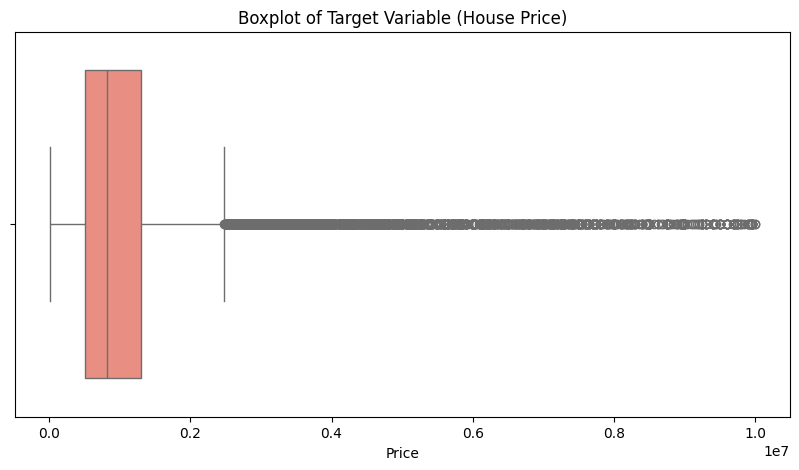

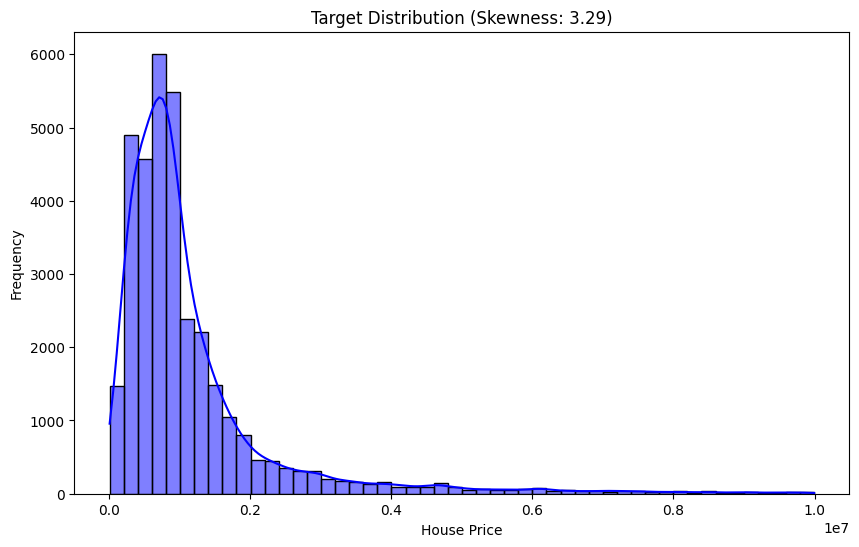

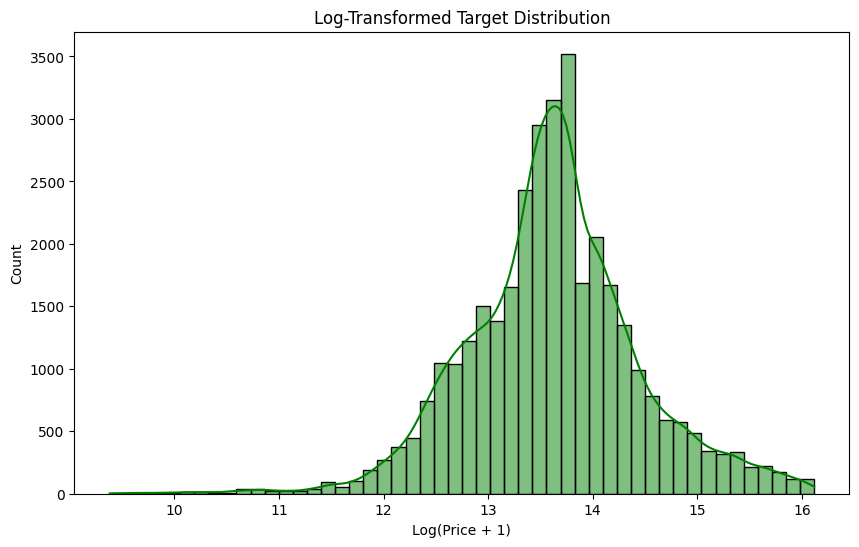

In [8]:
# check target value distribution and skewness
import seaborn as sns
import matplotlib.pyplot as plt

# Create a horizontal boxplot for the 'price' column
plt.figure(figsize=(10, 5))
sns.boxplot(x=clean_housingprice_df['sale_price'], color='salmon')

# Adding labels and title
plt.title("Boxplot of Target Variable (House Price)")
plt.xlabel("Price")
plt.show()

# Visualize the Raw Distribution
plt.figure(figsize=(10, 6))
sns.histplot(clean_housingprice_df['sale_price'], kde=True, color='blue', bins=50)

plt.title(f"Target Distribution (Skewness: {clean_housingprice_df['sale_price'].skew():.2f})")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

# Check for Log-Transformation (If skewness is high > 1)
import numpy as np
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(clean_housingprice_df['sale_price']), kde=True, color='green', bins=50)

plt.title("Log-Transformed Target Distribution")
plt.xlabel("Log(Price + 1)")
plt.show()

In [9]:
from sklearn.compose import TransformedTargetRegressor

# THIS TIME we will apply log transformation along with median numeric IMPUTER

# Imputation
num_transformer = SimpleImputer(strategy='median') # median numeric IMPUTER

# THIS TIME we will apply log transformation
model_with_log = TransformedTargetRegressor(
    regressor=pipeline, # pipeline remains same
    
    # Wrap the Pipeline in a Target Transformer
    # func=np.log1p applies log(1+x) to y before fitting
    # inverse_func=np.expm1 applies exp(x)-1 to predictions automatically
    func=np.log1p, 
    inverse_func=np.expm1
)

# Internally: y_train is converted to log scale, then the tree is trained
model_with_log.fit(X_train, y_train)

# Predict & Evaluate
# When predicting, the pipeline uses the MEANS calculated during training
y_pred = model_with_log.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model trained successfully!")
print(f"Test RMSE: {rmse:.2f}")

Model trained successfully!
Test RMSE: 1144379.55


In [10]:
# NOW we will back to full length features decision tree nodel with log transformation traget values

model = DecisionTreeRegressor(
    max_depth=10,            # Stop the tree from growing to infinity
    random_state=42
)

# Internally: y_train is converted to log scale, then the tree is trained
model_with_log.fit(X_train, y_train)

# Predict & Evaluate
# When predicting, the pipeline uses the MEANS calculated during training
y_pred = model_with_log.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model trained successfully!")
print(f"Test RMSE: {rmse:.2f}")

Model trained successfully!
Test RMSE: 1132290.14


In [11]:
# error percentage
error_percentage = rmse/housingprice_df['sale_price'].mean() * 100
print(f"Error percentage:  {error_percentage:0.3f}")

Error percentage:  96.626


In [12]:
from sklearn.metrics import r2_score

# r2 check
r2 = r2_score(y_test, y_pred)
print(f"R square: {r2:0.4f}")

R square: 0.2117


In [13]:
# individual error check
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

65.43633899039776


In [14]:
# THIS time we will try to find important features

# Access the preprocessor from your inner pipeline
# (Adjust 'preprocessor' if you named that step differently in your Pipeline)
preprocessor = model_with_log.regressor_.named_steps['preprocessor']

# Get the feature names after transformation
# This is the "magic" function in modern Scikit-Learn
feature_names = preprocessor.get_feature_names_out()

# Access the actual tree model
regressor = model_with_log.regressor_.named_steps['regressor']

# Combine them into a Series
importances = pd.Series(regressor.feature_importances_, index=feature_names)

# 5Sort and display
print("Feature Importances (Sorted):")
print(importances.sort_values(ascending=False))
print("Selected Features:")
selected_columns = list(map(lambda x: x[5:], feature_names.tolist()))
print(selected_columns)

Feature Importances (Sorted):
cat__zip_code     0.424360
cat__landuse      0.198504
cat__bldgclass    0.172094
num__numfloors    0.049116
cat__borough_x    0.043515
cat__borough_y    0.041155
num__resarea      0.037577
num__comarea      0.033679
dtype: float64
Selected Features:
['resarea', 'comarea', 'numfloors', 'borough_x', 'zip_code', 'borough_y', 'landuse', 'bldgclass']


In [15]:
# THIS time we will train on selected features

# Identify selected Columns
num_cols = [col for col in num_cols if col in selected_columns]
cat_cols = [col for col in cat_cols if col in selected_columns]

# Categorical: Target Encoding with smoothing
cat_transformer = TargetEncoder(smooth=50)

# THIS TIME we will apply log transformation
model_with_log = TransformedTargetRegressor(
    regressor=pipeline, # pipeline remains same
    
    # Wrap the Pipeline in a Target Transformer
    # func=np.log1p applies log(1+x) to y before fitting
    # inverse_func=np.expm1 applies exp(x)-1 to predictions automatically
    func=np.log1p, 
    inverse_func=np.expm1
)

# Split Data
X = clean_housingprice_df[selected_columns]
y = clean_housingprice_df['sale_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Internally: y_train is converted to log scale, then the tree is trained
model_with_log.fit(X_train, y_train)

# Predict & Evaluate
# When predicting, the pipeline uses the MEANS calculated during training
y_pred = model_with_log.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model trained successfully!")
print(f"Test RMSE: {rmse:.2f}")

# error percentage
error_percentage = rmse/clean_housingprice_df['sale_price'].mean() * 100
print(f"Error percentage:  {error_percentage:0.3f}")

# r2 check
r2 = r2_score(y_test, y_pred)
print(f"R square: {r2:0.4f}")

# individual error check
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

Model trained successfully!
Test RMSE: 1141713.44
Error percentage:  97.430
R square: 0.1802
69.45797218835882


In [16]:
# THIS time we will apply random forest

from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest Model
# n_estimators=100: We train 100 trees and average them
# n_jobs=-2: Use CPU cores for speed on local machine or laptop
rf_base = RandomForestRegressor(
    n_estimators=100, 
    max_depth=12,           # Slightly deeper than a single tree is okay
    min_samples_leaf=15,    # Prevents trees from memorizing outliers
    #max_features='sqrt',   # Essential for Random Forest diversity
    max_features = 1.0,     # i have selected all best features
    n_jobs=-2,              # Parallel processing for laptop or local machine
    random_state=42
)

# Wrap in Target Transformation (Log Scale)
model_final = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf', rf_base)
    ]),
    func=np.log1p, 
    inverse_func=np.expm1
)

# Train the Model
model_final.fit(X_train, y_train)

# Evaluate
y_pred = model_final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Results:")
print(f"Test RMSE: {rmse:,.2f}")
print(f"R-Squared: {r2:.4f}")

# individual error check
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

Random Forest Results:
Test RMSE: 1,054,280.14
R-Squared: 0.3010
63.60512930364198


In [17]:
# this time we will apply max_features = 0.5
rf_base = RandomForestRegressor(
    n_estimators=100, 
    max_depth=12,           # Slightly deeper than a single tree is okay
    min_samples_leaf=15,    # Prevents trees from memorizing outliers
    #max_features='sqrt',   # Essential for Random Forest diversity
    max_features = 0.5,     # i have selected all best features, taking half of them randomly
    n_jobs=-2,              # Parallel processing for laptop or local machine
    random_state=42
)

# Train the Model
model_final.fit(X_train, y_train)

# Evaluate
y_pred = model_final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Results:")
print(f"Test RMSE: {rmse:,.2f}")
print(f"R-Squared: {r2:.4f}")

# individual error check
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

Random Forest Results:
Test RMSE: 1,067,803.67
R-Squared: 0.2829
63.79077661687449


In [18]:
# this time we will try some higher depth and modified smoothing for target encoding

# Categorical: Target Encoding with smoothing
cat_transformer = TargetEncoder(smooth=80)

rf_base = RandomForestRegressor(
    n_estimators=100, 
    max_depth=40,           # Slightly deeper than a single tree is okay
    min_samples_leaf=5,    # Prevents trees from memorizing outliers
    #max_features='sqrt',   # Essential for Random Forest diversity
    max_features = 1.0,     # i have selected all best features, taking half of them randomly
    n_jobs=-2,              # Parallel processing for laptop or local machine
    random_state=42
)

# Train the Model
model_final.fit(X_train, y_train)

# Evaluate
y_pred = model_final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Results:")
print(f"Test RMSE: {rmse:,.2f}")
print(f"R-Squared: {r2:.4f}")

# individual error check
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

Random Forest Results:
Test RMSE: 1,048,435.64
R-Squared: 0.3087
63.11756097672097


In [20]:
# THIS TIME we will try boosting

from xgboost import XGBRegressor

# Define the XGBoost Model
# XGBoost is very powerful; we use 'learning_rate' to prevent overfitting
xgb_base = XGBRegressor(
    n_estimators=1000,     # High number of trees (Boosting handles this well)
    learning_rate=0.05,    # Small steps to "slowly" learn the complex patterns
    max_depth=5,           # XGBoost trees are usually shallower than RF
    subsample=0.8,         # Use 80% of data per tree to prevent memorizing outliers
    colsample_bytree=0.8,  # Similar to max_features='sqrt'
    n_jobs=-2,             # for local machine and laptop
    random_state=42,
    tree_method='hist'     # High-speed method for 35k+ rows
)

# Wrap in Target Transformation (Log Scale)
boosting_model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('xgb', xgb_base)
    ]),
    func=np.log1p, 
    inverse_func=np.expm1
)

# Train the Model
boosting_model.fit(X_train, y_train)

# Evaluate
y_pred = boosting_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoosting Results:")
print(f"Test RMSE: {rmse:,.2f}")
print(f"R-Squared: {r2:.4f}")

# individual error check
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(mape)

XGBoosting Results:
Test RMSE: 1,001,044.75
R-Squared: 0.3698
63.31038475036621
